# BAB V — Implementasi dan Pengujian
## Identifikasi Biometrik Telapak Tangan Menggunakan Model Embedding

Versi ini memakai **preprocessing/ROI yang sama dengan palm_embedding.ipynb** (MediaPipe Hand Landmarker + CLAHE + *quality gate*). **Augmentasi** dan **perilaku fine-tuning** mengikuti palm_classification, sedangkan **evaluasi (cross-validation + EER)** dan **penanganan kiri/kanan tangan** mengikuti palm_embedding.

1. **5.1 Ekstraksi ROI** — MediaPipe Hand Landmarker + CLAHE + quality gate. *(identik palm_embedding)*
2. **5.2 Pelatihan Model Embedding** — EfficientNetB0 (beku) + kepala softmax "guru", embedding 128-D; augmentasi & fine-tuning *(gaya palm_classification)*.
3. **5.3 Pengujian Sistem** — cross-validation, EER ± 95% CI (bootstrap), AUC, Rank-1/FRR/OpenFA, TTA. *(identik palm_embedding)*
4. **5.4 Model Final & Ekspor** — latih pada semua identitas, simpan .keras + TFLite + metadata.

> Catatan: setiap sel kode diberi komentar yang menjelaskan fungsi, nilai parameter/variabel, dan teknik yang dipakai.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# 5.1 Ekstraksi ROI (MediaPipe + CLAHE + Quality Gate)

Tahap ROI **identik dengan palm_embedding.ipynb**: deteksi titik tangan dengan **MediaPipe Hand Landmarker**, putar & potong area telapak, terapkan **CLAHE**, lalu saring citra yang terlalu kabur (*quality gate*). Parameter dibuat sama agar konsisten dengan perangkat (device).

## 5.1.1 Konfigurasi

Parameter ROI (CLAHE, skala ROI, ambang lebar telapak & ketajaman) mengikuti palm_embedding. Parameter model & pelatihan mengikuti palm_classification, parameter cross-validation/TTA mengikuti palm_embedding.

In [2]:
import os, json, math, random, glob
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import roc_curve, auc

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

# --- Path ---
RAW_DIR      = '/content/drive/MyDrive/Skripsi/dataset_mentah'   # data mentah: <orang>/*.jpg
ROI_DIR      = '/content/drive/MyDrive/Skripsi/dataset_roi'       # hasil ROI: <orang>/*.png
SAVE_DIR     = '/content/drive/MyDrive/Skripsi/models'            # tempat menyimpan model
LANDMARKER   = 'hand_landmarker.task'                            # model MediaPipe Hand Landmarker
ARTIFACT_DIR = 'artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# --- Preprocessing / ROI (IDENTIK palm_embedding.ipynb; harus sama dengan device) ---
IMG_SIZE       = (224, 224)   # ukuran input EfficientNet
CLAHE_CLIP     = 2.0          # batas kontras CLAHE
CLAHE_TILE     = (8, 8)       # ukuran grid CLAHE
PALM_ROI_SCALE = 1.5          # skala kotak ROI relatif lebar telapak
MIN_PALM_WIDTH = 40.0         # lebar telapak minimum (px) -> tolak deteksi buruk
MIN_SHARPNESS  = 25.0         # ketajaman minimum (variance Laplacian) -> tolak blur

# --- Model (identik palm_classification) ---
EMBED_DIM = 128   # panjang vektor embedding
BATCH     = 32    # batch size

# --- Pelatihan (perilaku fine-tuning IDENTIK palm_classification) ---
LR          = 1e-4   # Adam learning rate 0.0001
EPOCHS      = 100    # epoch maksimum
ES_PATIENCE = 5      # EarlyStopping patience

# --- Penanganan kiri/kanan tangan (sama seperti palm_embedding.ipynb) ---
SPLIT_BY_HAND_TRAIN = False   # True -> kiri/kanan jadi kelas berbeda saat TRAIN (eval tetap per-orang)

# --- Evaluasi Cross-Validation (sama seperti palm_embedding.ipynb) ---
N_GALLERY       = 4      # citra per tangan untuk enrollment (template)
N_TEST_ENROLLED = 3      # identitas terdaftar per fold
N_TEST_UNKNOWN  = 3      # identitas asing (impostor) per fold
N_VAL_IDS       = 4      # identitas untuk validasi EER saat training
N_FOLDS         = 10     # jumlah fold
TTA_ROTATIONS   = [0.0, -6.0, 6.0]   # Test-Time Augmentation
TARGET_FAR      = [0.001, 0.01]      # target FAR untuk pemilihan threshold
BOOTSTRAP_B     = 2000               # iterasi bootstrap untuk 95% CI

print('TF:', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 5.1.2 Setup & Ekstraksi ROI (MediaPipe) + Quality Gate

Pasang dependensi dan unduh model **hand_landmarker.task** (bila belum ada). `extract_palm_roi()` mendeteksi 21 titik tangan, meluruskan & memotong telapak, lalu menerapkan CLAHE; `roi_sharpness()` dipakai sebagai gerbang kualitas. *(identik palm_embedding)*

In [3]:
!pip install -q tensorflow numpy mediapipe scikit-learn matplotlib tqdm
# Unduh model MediaPipe Hand Landmarker bila belum tersedia (dibutuhkan extract_palm_roi)
import os, urllib.request
if not os.path.exists(LANDMARKER):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task',
        LANDMARKER)
    print('Downloaded', LANDMARKER)
else:
    print(LANDMARKER, 'sudah ada')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.1 MB/s eta 0:00:00
Downloaded hand_landmarker.task


In [4]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

_base = mp_python.BaseOptions(model_asset_path=LANDMARKER)
_opts = vision.HandLandmarkerOptions(base_options=_base, num_hands=1,
                                     running_mode=vision.RunningMode.IMAGE)
_landmarker = vision.HandLandmarker.create_from_options(_opts)
_clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

def roi_sharpness(roi_rgb):
    g = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2GRAY)
    return float(cv2.Laplacian(g, cv2.CV_64F).var())

def extract_palm_roi(bgr):
    h, w = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    res = _landmarker.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))
    if not res.hand_landmarks:
        return None
    lm = res.hand_landmarks[0]
    def p(i):
        return np.array([lm[i].x * w, lm[i].y * h], dtype=np.float32)
    wrist, idx_mcp, mid_mcp, pinky_mcp = p(0), p(5), p(9), p(17)
    palm_w = float(np.linalg.norm(idx_mcp - pinky_mcp))
    if palm_w < MIN_PALM_WIDTH:
        return None
    angle = math.degrees(math.atan2(pinky_mcp[1]-idx_mcp[1], pinky_mcp[0]-idx_mcp[0]))
    center = (wrist + mid_mcp) / 2.0
    R = cv2.getRotationMatrix2D((float(center[0]), float(center[1])), angle, 1.0)
    rot = cv2.warpAffine(bgr, R, (w, h))
    half = (palm_w * PALM_ROI_SCALE) / 2.0
    cx, cy = float(center[0]), float(center[1])
    x1, y1 = int(max(0, cx-half)), int(max(0, cy-half))
    x2, y2 = int(min(w, cx+half)), int(min(h, cy+half))
    crop = rot[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    gray = _clahe.apply(cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY))
    roi = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    return cv2.resize(roi, IMG_SIZE, interpolation=cv2.INTER_CUBIC)

## 5.1.3 Bangun Dataset ROI (sekali jalan)

`hand_of()` membaca penanda kiri/kanan dari nama file; `_retry_detect()` mencoba beberapa rotasi/flip bila deteksi gagal; `build_roi_dataset()` menyimpan ROI ke `ROI_DIR/<orang>/*.png`. *(identik palm_embedding)*

In [5]:
SKIP_IF_EXISTS = True

def hand_of(filename):
    parts = os.path.splitext(filename)[0].split('_')
    if len(parts) >= 3 and parts[2].upper() in ('L', 'R'):
        return parts[2].upper()
    f = filename.lower()
    if any(k in f for k in ['left', 'kiri']):  return 'L'
    if any(k in f for k in ['right', 'kanan']): return 'R'
    return 'X'

def _retry_detect(img):
    roi = extract_palm_roi(img)
    if roi is not None:
        return roi
    for op in [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_90_COUNTERCLOCKWISE, cv2.ROTATE_180]:
        roi = extract_palm_roi(cv2.rotate(img, op))
        if roi is not None:
            return roi
    return extract_palm_roi(cv2.flip(img, 1))

In [6]:
def build_roi_dataset():
    if SKIP_IF_EXISTS and os.path.isdir(ROI_DIR) and any(
            os.path.isdir(os.path.join(ROI_DIR, d)) for d in os.listdir(ROI_DIR)):
        print('ROI_DIR sudah berisi data; lewati ekstraksi.')
        return
    persons = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])
    ok = miss = blur = bad = 0
    for person in tqdm(persons, desc='ROI'):
        pdir = os.path.join(RAW_DIR, person)
        for fn in sorted(os.listdir(pdir)):
            if not fn.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                continue
            img = cv2.imread(os.path.join(pdir, fn))
            if img is None:
                bad += 1; continue
            roi = _retry_detect(img)
            if roi is None:
                miss += 1; continue
            if roi_sharpness(roi) < MIN_SHARPNESS:
                blur += 1; continue
            outdir = os.path.join(ROI_DIR, person)
            os.makedirs(outdir, exist_ok=True)
            cv2.imwrite(os.path.join(outdir, os.path.splitext(fn)[0] + '.png'),
                        cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))
            ok += 1
    print('Selesai. ok=', ok, '| gagal_baca=', bad, '| gagal_deteksi=', miss, '| ditolak_blur=', blur)

build_roi_dataset()

ROI: 100%|██████████| 28/28 [17:06<00:00, 36.65s/it]

Selesai. ok= 1009 | gagal_baca= 0 | gagal_deteksi= 111 | ditolak_blur= 0


---
# 5.2 Implementasi Pelatihan Model Embedding

Model embedding dilatih dengan **kepala softmax sebagai "guru"** lalu kepala dilepas. Augmentasi, base EfficientNetB0 (beku), Adam(1e-4), categorical_crossentropy, dan EarlyStopping dibuat **identik palm_classification**. Indeks identitas & template dibangun **per tangan** seperti palm_embedding.

## 5.2.1 Indeks Identitas & Helper Embedding (+ TTA)

Menyusun daftar identitas (tahan terhadap layout `<orang>/` maupun `train/val/test/<orang>/`) dan `embed_paths()` ber-L2-norm dengan TTA. *(evaluasi & TTA mengikuti palm_embedding)*

In [7]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def _list_imgs(d):
    return [os.path.join(d, f) for f in os.listdir(d)
            if os.path.isfile(os.path.join(d, f)) and f.lower().endswith(IMG_EXTS)]

# Bangun peta identitas -> daftar file. Mendukung DUA tata letak folder ROI:
#   (a) ROI_DIR/<orang>/*.png
#   (b) ROI_DIR/<split>/<orang>/*.png  (mis. train/val/test) -> otomatis digabung per orang
ID_TO_FILES = {}
_top = sorted([d for d in os.listdir(ROI_DIR) if os.path.isdir(os.path.join(ROI_DIR, d))])
for d in _top:
    dpath = os.path.join(ROI_DIR, d)
    direct = _list_imgs(dpath)
    if direct:                       # (a) d adalah folder orang (langsung berisi citra)
        ID_TO_FILES.setdefault(d, []).extend(direct)
    else:                            # (b) d adalah split -> turun satu level ke folder orang
        for sub in sorted(os.listdir(dpath)):
            subp = os.path.join(dpath, sub)
            if os.path.isdir(subp):
                ID_TO_FILES.setdefault(sub, []).extend(_list_imgs(subp))

ID_TO_FILES = {k: sorted(v) for k, v in ID_TO_FILES.items() if v}
ALL_IDS = sorted(ID_TO_FILES)
print('Total identitas:', len(ALL_IDS),
      '| total citra:', sum(len(v) for v in ID_TO_FILES.values()))
_need = N_TEST_ENROLLED + N_TEST_UNKNOWN + N_VAL_IDS + 1
assert len(ALL_IDS) >= _need, (
    'Identitas terbaca %d, butuh minimal %d. ROI_DIR kosong atau struktur folder salah. '
    'Pastikan ROI sudah dibuat (sel 5.2.2) dan tiap orang punya foldernya sendiri.' % (len(ALL_IDS), _need))

def imgs_of(label):
    return ID_TO_FILES.get(label, [])

def load_img(path):
    return cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), IMG_SIZE).astype(np.float32)

def _rotate(img, deg):
    if deg == 0:
        return img
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2.0, h/2.0), deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

def embed_paths(model, paths, tta=None, batch=64):
    if tta is None:
        tta = TTA_ROTATIONS
    if len(paths) == 0:
        return np.zeros((0, EMBED_DIM), np.float32)
    base = [load_img(p) for p in paths]
    accum = np.zeros((len(paths), EMBED_DIM), np.float32)
    for deg in tta:
        e = model.predict(np.stack([_rotate(im, deg) for im in base]), verbose=0, batch_size=batch)
        accum += e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-9)
    accum /= len(tta)
    return (accum / (np.linalg.norm(accum, axis=1, keepdims=True) + 1e-9)).astype(np.float32)

Total identitas: 28 | total citra: 1009


## 5.2.2 Model, Augmentasi & Rutin Pelatihan

EfficientNetB0 (beku) + GlobalAveragePooling + Dropout(0.3) + Dense(128). `fit_model()` melatih satu model per kumpulan identitas dengan perilaku **identik palm_classification**, mendukung opsi kiri/kanan (`SPLIT_BY_HAND_TRAIN`).

In [8]:
def make_augment():
    # Augmentasi identik palm_classification: flip horizontal + rotasi 10% + zoom 10%
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name="augment")

def build_embedding_model(embed_dim=EMBED_DIM):
    # EfficientNetB0 dibekukan (transfer learning) -> perilaku fine-tuning identik palm_classification
    backbone = EfficientNetB0(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
    backbone.trainable = False
    inp = Input(IMG_SIZE + (3,))
    x = tf.keras.applications.efficientnet.preprocess_input(inp)   # normalisasi khas EfficientNet
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)                                     # dropout 30% (regularisasi)
    x = layers.Dense(embed_dim, name="embedding")(x)               # lapisan embedding 128-D
    return models.Model(inp, x, name="embedding_model"), backbone

def build_train_model(num_classes):
    # Model pelatihan: citra -> augmentasi -> embedding -> kepala softmax ("guru")
    em, bb = build_embedding_model()
    img_in = Input(IMG_SIZE + (3,), name="image")
    emb = em(make_augment()(img_in))
    out = layers.Dense(num_classes, activation="softmax", name="klasifikasi")(emb)
    return models.Model(img_in, out, name="trainer"), em

In [9]:
def _ds_from(paths, labels, num_classes):
    # tf.data dari daftar path -> (citra 0-255 float32, one-hot)
    def _load(p, y):
        img = tf.cast(tf.image.resize(tf.io.decode_png(tf.io.read_file(p), channels=3), IMG_SIZE), tf.float32)
        return img, tf.one_hot(y, num_classes)
    assert len(paths) > 0, 'Tidak ada citra untuk train_ids ini. Cek ROI_DIR dan struktur folder (<orang>/*.png).'
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)).shuffle(max(1, len(paths)), seed=SEED)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

def build_train_index(train_ids, split_by_hand):
    # Susun daftar kelas + file per kelas. split_by_hand=True -> kiri/kanan jadi kelas terpisah.
    classes, pbc = [], {}
    for pid in train_ids:
        files = imgs_of(pid)
        if split_by_hand:
            g = {}
            for f in files:
                g.setdefault(hand_of(os.path.basename(f)), []).append(f)
            for h, fs in g.items():
                c = pid + "__" + h; classes.append(c); pbc[c] = fs
        else:
            classes.append(pid); pbc[pid] = files
    return classes, pbc

class EERValidation(tf.keras.callbacks.Callback):
    # Hitung EER pada identitas validasi tiap akhir epoch -> dipakai EarlyStopping (val_eer)
    def __init__(self, em, val_ids, n_gallery=N_GALLERY):
        super().__init__(); self.em = em
        self.files = {p: imgs_of(p) for p in val_ids}; self.n_gallery = n_gallery
    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        tem, prb = {}, []
        for p, fs in self.files.items():
            fs2 = list(fs); random.Random(SEED).shuffle(fs2)
            g, q = fs2[:self.n_gallery], fs2[self.n_gallery:]
            if not g or not q:
                continue
            t = embed_paths(self.em, g, tta=[0.0]).mean(0); tem[p] = t / (np.linalg.norm(t) + 1e-9)
            for v in embed_paths(self.em, q, tta=[0.0]):
                prb.append((v, p))
        if len(tem) < 2 or not prb:
            logs["val_eer"] = 1.0; return
        ids = list(tem); M = np.stack([tem[i] for i in ids]); gen, imp = [], []
        for v, tp in prb:
            sims = M @ v
            for i, idp in enumerate(ids):
                (gen if idp == tp else imp).append(float(sims[i]))
        fpr, tpr, _ = roc_curve(np.r_[np.ones(len(gen)), np.zeros(len(imp))], np.r_[gen, imp])
        fnr = 1 - tpr; i = int(np.nanargmin(np.abs(fpr - fnr)))
        logs["val_eer"] = float((fpr[i] + fnr[i]) / 2.0)

def fit_model(train_ids, val_ids=None, split_by_hand=SPLIT_BY_HAND_TRAIN):
    # Latih SATU model embedding. Perilaku fine-tuning identik palm_classification
    # (EfficientNet beku, Adam 1e-4, categorical_crossentropy, EarlyStopping).
    tf.keras.backend.clear_session()
    classes, pbc = build_train_index(train_ids, split_by_hand)
    nc = len(classes); idx = {c: i for i, c in enumerate(classes)}
    paths, labels = [], []
    for c in classes:
        for f in pbc[c]:
            paths.append(f); labels.append(idx[c])
    ds = _ds_from(paths, labels, nc)
    trainer, em = build_train_model(nc)
    trainer.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    cbs = []
    if val_ids:
        # Validasi memakai EER (sesuai skema cross-validation palm_embedding)
        cbs.append(EERValidation(em, val_ids))
        cbs.append(tf.keras.callbacks.EarlyStopping(monitor="val_eer", mode="min",
                                                    patience=ES_PATIENCE, restore_best_weights=True))
    trainer.fit(ds, epochs=EPOCHS, callbacks=cbs, verbose=0)
    return em

---
# 5.3 Pengujian Sistem (Cross-Validation)

Skema cross-validation identik palm_embedding: tiap fold membagi identitas (train/enrolled/unknown/val), model dilatih ulang per fold, skor di-pool menjadi EER ± 95% CI.

## 5.3.1 Evaluasi per Fold (enroll + probe + unknown)

Template dibangun **per tangan (kiri/kanan)**; pencocokan memakai **MAX cosine**; identitas *unknown* sebagai impostor open-set. *(identik palm_embedding)*

In [10]:
def evaluate_fold(em, enrolled_ids, unknown_ids):
    templates, probes = {}, []
    for pid in enrolled_ids:
        by_hand = {}
        for f in imgs_of(pid):
            by_hand.setdefault(hand_of(os.path.basename(f)), []).append(f)
        temps, pf = [], []
        for h, fs in by_hand.items():
            fs = list(fs); random.Random(SEED).shuffle(fs)
            g, q = fs[:N_GALLERY], fs[N_GALLERY:]
            if g:
                t = embed_paths(em, g).mean(0); temps.append(t / (np.linalg.norm(t) + 1e-9))
            pf += q
        if temps:
            templates[pid] = np.stack(temps)
        for v in embed_paths(em, pf):
            probes.append((v, pid))
    persons = list(templates)
    def ps(v, pid):
        return float(np.max(templates[pid] @ v))
    gen, imp, probe_best = [], [], []
    for v, tp in probes:
        sc = {pid: ps(v, pid) for pid in persons}
        for pid in persons:
            (gen if pid == tp else imp).append(sc[pid])
        bp = max(sc, key=sc.get); probe_best.append((sc[bp], bp == tp))
    unk_imp, unk_max = [], []
    for pid in unknown_ids:
        for v in embed_paths(em, imgs_of(pid)):
            s = [ps(v, q) for q in persons]; unk_imp += s; unk_max.append(max(s))
    return dict(gen=gen, imp=imp + unk_imp, probe_best=probe_best, unk_max=unk_max)

## 5.3.2 Cross-Validation Loop (pooled EER ± 95% CI)

Melaporkan EER per-fold (mean ± 95% CI), EER pooled + bootstrap CI, AUC, ROC, serta Rank-1/FRR/OpenFA pada target FAR. *(identik palm_embedding)*

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fold 1 / 10 | train= 18 | EER=3.66%
Fold 2 / 10 | train= 18 | EER=3.68%
Fold 3 / 10 | train= 18 | EER=1.33%
Fold 4 / 10 | train= 18 | EER=2.53%
Fold 5 / 10 | train= 18 | EER=3.82%
Fold 6 / 10 | train= 18 | EER=12.47%
Fold 7 / 10 | train= 18 | EER=6.20%
Fold 8 / 10 | train= 18 | EER=0.43%
Fold 9 / 10 | train= 18 | EER=2.08%
Fold 10 / 10 | train= 18 | EER=4.37%

==== HASIL CROSS-VALIDATION ====
Fold=10 | identitas teruji=26/28
EER per-fold: mean=4.06% +/-2.09% (95%CI) | min=0.43% max=12.47%
EER pooled  : 5.00% | bootstrap 95%CI=[4.22%, 6.15%] | AUC=0.9844

Threshold pada target FAR (skor pooled):
  FAR<=0.1% -> thr=0.9311 | Rank-1=83.00% | FRR=17.00% | OpenFA=0.38%
  FAR<=1.0% -> thr=0.9143 | Rank-1=89.49% | FRR=10.51% | OpenFA=4.05%


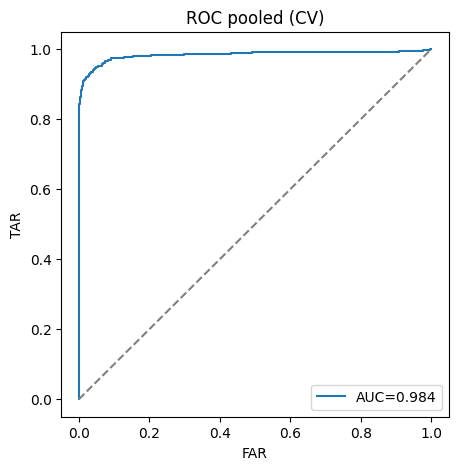

In [11]:
def make_folds(all_ids, k, n_enr, n_unk, n_val, seed=SEED):
    fl = []
    for f in range(k):
        ids = list(all_ids); random.Random(seed + f).shuffle(ids)
        a, b, c = n_enr, n_enr + n_unk, n_enr + n_unk + n_val
        fl.append(dict(enrolled=ids[:a], unknown=ids[a:b], val=ids[b:c], train=ids[c:]))
    return fl

def compute_eer(gen, imp):
    fpr, tpr, thr = roc_curve(np.r_[np.ones(len(gen)), np.zeros(len(imp))], np.r_[gen, imp])
    fnr = 1 - tpr; i = int(np.nanargmin(np.abs(fpr - fnr)))
    return float(auc(fpr, tpr)), float((fpr[i] + fnr[i]) / 2.0), fpr, tpr, thr

def bootstrap_eer(gen, imp, B=BOOTSTRAP_B, seed=SEED):
    rng = np.random.default_rng(seed); gen = np.asarray(gen); imp = np.asarray(imp); out = []
    for _ in range(B):
        _, e, _, _, _ = compute_eer(rng.choice(gen, len(gen), True), rng.choice(imp, len(imp), True))
        out.append(e)
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))

folds = make_folds(ALL_IDS, N_FOLDS, N_TEST_ENROLLED, N_TEST_UNKNOWN, N_VAL_IDS)
G, I, per_fold_eer, all_pb, all_unk, tested = [], [], [], [], [], set()
for k, fd in enumerate(folds):
    em = fit_model(fd['train'], fd['val'])
    r = evaluate_fold(em, fd['enrolled'], fd['unknown'])
    g, im = np.array(r['gen']), np.array(r['imp'])
    _, eer, _, _, _ = compute_eer(g, im); per_fold_eer.append(eer)
    G.append(g); I.append(im); all_pb += r['probe_best']; all_unk += r['unk_max']
    tested |= set(fd['enrolled']) | set(fd['unknown'])
    print('Fold', k + 1, '/', N_FOLDS, '| train=', len(fd['train']), '| EER=%.2f%%' % (eer * 100))

G, I = np.concatenate(G), np.concatenate(I)
AUC, EER, fpr, tpr, thr = compute_eer(G, I); lo, hi = bootstrap_eer(G, I); pf = np.array(per_fold_eer)
print('\n==== HASIL CROSS-VALIDATION ====')
print('Fold=%d | identitas teruji=%d/%d' % (N_FOLDS, len(tested), len(ALL_IDS)))
print('EER per-fold: mean=%.2f%% +/-%.2f%% (95%%CI) | min=%.2f%% max=%.2f%%' % (
    pf.mean() * 100, 1.96 * pf.std(ddof=1) / np.sqrt(len(pf)) * 100, pf.min() * 100, pf.max() * 100))
print('EER pooled  : %.2f%% | bootstrap 95%%CI=[%.2f%%, %.2f%%] | AUC=%.4f' % (EER * 100, lo * 100, hi * 100, AUC))

def thr_at_far(ft):
    ok = np.where(fpr <= ft)[0]; return float(thr[ok[-1] if len(ok) else 0])

print('\nThreshold pada target FAR (skor pooled):')
for ft in TARGET_FAR:
    T = thr_at_far(ft)
    rank1 = np.mean([(s >= T and ok) for s, ok in all_pb])
    frr = np.mean([s < T for s, _ in all_pb])
    openfa = np.mean([s >= T for s in all_unk]) if all_unk else 0.0
    print('  FAR<=%.1f%% -> thr=%.4f | Rank-1=%.2f%% | FRR=%.2f%% | OpenFA=%.2f%%' % (
        ft * 100, T, rank1 * 100, frr * 100, openfa * 100))

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='AUC=%.3f' % AUC); plt.plot([0, 1], [0, 1], '--', c='gray')
plt.xlabel('FAR'); plt.ylabel('TAR'); plt.title('ROC pooled (CV)'); plt.legend(); plt.show()

---
# 5.4 Latih Model Final (semua identitas) & Ekspor

Model final dilatih pada semua identitas lalu diekspor ke `.keras`, TFLite (float32), dan `model_metadata.json`.

In [13]:
# CV sudah memberi estimasi jujur; model final dilatih pada SEMUA identitas.
embedding_model = fit_model(ALL_IDS, val_ids=ALL_IDS[:N_VAL_IDS])
OPERATING_FAR = max(TARGET_FAR)
OPERATING_THRESHOLD = thr_at_far(OPERATING_FAR)
print("OPERATING_THRESHOLD =", round(OPERATING_THRESHOLD, 4))

os.makedirs(SAVE_DIR, exist_ok=True)
embedding_model.save(os.path.join(SAVE_DIR, "palm_embedding.keras"))

# Ekspor TFLite (float32 = akurasi terbaik)
conv = tf.lite.TFLiteConverter.from_keras_model(embedding_model)
with open(os.path.join(SAVE_DIR, "palm_embedding.tflite"), "wb") as f:
    f.write(conv.convert())

meta = {
    "embedding_dim": EMBED_DIM,
    "img_size": list(IMG_SIZE),
    "input_range": "0-255 float32 (preprocess_input EfficientNet di dalam model)",
    "similarity": "cosine L2-norm",
    "operating_threshold": OPERATING_THRESHOLD,
    "operating_far": OPERATING_FAR,
    "cv_eer_pooled": EER,
    "cv_eer_ci95": [lo, hi],
    "cv_auc": AUC,
    "tta_rotations": TTA_ROTATIONS,
    "split_by_hand_train": SPLIT_BY_HAND_TRAIN,
    "preprocessing": "MediaPipe ROI -> gray -> CLAHE(2.0,8x8) -> GRAY2RGB -> resize 224",
}
with open(os.path.join(SAVE_DIR, "model_metadata.json"), "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))

OPERATING_THRESHOLD = 0.9143
Saved artifact at '/tmp/tmpo4haupog'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 128), dtype=tf.float32, name=None)
Captures:
  132086394297168: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132086394297936: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132092467491088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132092467490512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132092467489168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132092467491856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132092467492432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132092467490896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132092467489360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132092467492240: TensorSpec(sha